In [11]:
import carla 
import math 
import random 
import time 
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from map_visualization import MapVisualization
import pprint
import json

import lanelet2
from lanelet2.io import load, Origin
from lanelet2.projection import LocalCartesianProjector, UtmProjector
from lanelet2.core import BasicPoint2d, BasicPoint3d, LineString2d, LaneletMap
from lanelet2.routing import RoutingGraph, RoutingCost, RoutingCostDistance
from lanelet2.traffic_rules import create as create_traffic_rules
from lanelet2.geometry import to2D, project

from util import get_full_trajectory, resample_centerline, compute_s0, slice_centerline, path_length, distance2d

In [5]:
# Connect the client and set up bp library and spawn points
client = carla.Client('localhost', 2000) 
world = client.get_world()
bp_lib = world.get_blueprint_library() 
spawn_points = world.get_map().get_spawn_points() 
tm = client.get_trafficmanager(8000)
tm_port = tm.get_port()

In [ ]:
# Load map and setup
map_path = os.path.expanduser('~/Documents/town_10/backup/lanelet2_map.osm')
assert os.path.exists(map_path), f"Map file not found at {map_path}"
proj = LocalCartesianProjector(Origin(0, 0, 0))
lanelet_map = load(map_path, proj)
traffic_rules = create_traffic_rules("de", "vehicle")
router = RoutingGraph(lanelet_map, traffic_rules, [RoutingCostDistance(1.0)])

# Vehicle position and heading
pt = BasicPoint2d(vehicle.get_location().x, -vehicle.get_location().y)
yaw = vehicle.get_transform().rotation.yaw  # in degrees
yaw_rad = math.radians(yaw)
v_veh = (-math.cos(yaw_rad), -math.sin(yaw_rad))  # Direction in map coordinates

# Find candidate lanelets within 5 meters
candidates = [ll for ll in lanelet_map.laneletLayer if lanelet2.geometry.distance(ll, pt) < 1.0]

# Select lanelet aligned with vehicle's direction
best_lanelet = None
max_dot = -float('inf')
for ll in candidates:
    # 1) Project vehicle point onto this lanelet’s 3D centerline
    pt3d    = BasicPoint3d(pt.x, pt.y, 0.0)
    proj_pt = lanelet2.geometry.project(ll.centerline, pt3d)

    # 2) Find which segment of ll.centerline is closest to proj_pt
    best_i, best_dist = 0, float('inf')
    pts = ll.centerline
    for idx in range(len(pts) - 1):
        p0, p1 = pts[idx], pts[idx+1]
        dx, dy = p1.x - p0.x, p1.y - p0.y
        ux, uy = proj_pt.x - p0.x, proj_pt.y - p0.y
        denom  = dx*dx + dy*dy
        u = (ux*dx + uy*dy) / denom if denom > 0 else 0.0
        u_clamped = max(0.0, min(1.0, u))
        cx, cy = p0.x + u_clamped*dx, p0.y + u_clamped*dy
        d = math.hypot(cx - pt.x, cy - pt.y)
        if d < best_dist:
            best_dist, best_i = d, idx
    
    # 3) Compute this lanelet’s local direction vector
    p0 = pts[best_i]
    p1 = pts[best_i+1]
    v_lane = (p1.x - p0.x, p1.y - p0.y)

    # 4) Compute dot with vehicle’s heading unit vector v_veh
    dot = v_lane[0]*v_veh[0] + v_lane[1]*v_veh[1]
    if dot > max_dot:
        max_dot     = dot
        best_lanelet = ll
        
if best_lanelet is None:
    raise ValueError("No suitable lanelet found near the vehicle")

current_lane = best_lanelet
closest_lanelet_traj = get_full_trajectory(current_lane, router, max_length=50.0, spacing=3.0)
closest_lanelet_traj = np.array(closest_lanelet_traj)

proj_pt = lanelet2.geometry.project(current_lane.centerline, pt3d)
s0 = compute_s0(current_lane.centerline, proj_pt)
print('s0:', s0)
slice_pts = slice_centerline(current_lane.centerline, s0, 50.0)
sliced_trajectory = [(p.x, p.y) for p in slice_pts]
sliced_trajectory_1 = np.array(sliced_trajectory)

following = router.following(current_lane)
branch_lane_1 = following[0]
s0 = compute_s0(branch_lane_1.centerline, proj_pt)
slice_pts = slice_centerline(branch_lane_1.centerline, s0, 50.0)
sliced_trajectory = [(p.x, p.y) for p in slice_pts]
sliced_trajectory_2 = np.array(sliced_trajectory)

following = router.following(current_lane)
branch_lane_2 = following[1]
s0 = compute_s0(branch_lane_2.centerline, proj_pt)
slice_pts = slice_centerline(branch_lane_2.centerline, s0, 50.0)
sliced_trajectory = [(p.x, p.y) for p in slice_pts]
sliced_trajectory_3 = np.array(sliced_trajectory)



all_paths = collect_trajectories(
    lanelet_map,
    router,
    best_lanelet,
    pt3d,
    budget=50.0
)
sliced_trajectory = [(p.x, p.y) for p in all_paths[0]]
sliced_trajectory_4 = np.array(sliced_trajectory)
print(sliced_trajectory_4)

sliced_trajectory = [(p.x, p.y) for p in all_paths[1]]
sliced_trajectory_5 = np.array(sliced_trajectory)
print(sliced_trajectory_5)



In [26]:
def collect_trajectories_v3(lanelet_map, router, current_lane, proj_pt, budget=50.0,
                         visited=None, connection_tol=5.0, original_lane=None, yaw=None,
                         enter_threshold=2.0, angle_thresh_deg=80.0):

    if visited is None:
        visited = set()
    visited.add(current_lane.id)
    print("current_lane", current_lane.id)

    # Keep reference to original_lane
    if original_lane is None:
        original_lane = current_lane

    # Project ego point onto centerline
    proj_pt3d = project(current_lane.centerline, proj_pt)
    s0 = compute_s0(current_lane.centerline, proj_pt3d)
    main_slice = slice_centerline(current_lane.centerline, s0, budget)

    if path_length(main_slice) >= budget:
        return [main_slice]

    # Freeze lanelet choice if ego hasn’t moved far enough
    if s0 < enter_threshold: # path_length(main_slice) < enter_threshold
        lane_for_successors = original_lane
    else:
        lane_for_successors = current_lane

    successors = router.following(lane_for_successors)
    if not successors:
        return [main_slice]

    # Set up heading vector from yaw (in radians)
    if yaw is None:
        # Approximate heading from initial segment
        if len(main_slice) >= 2:
            dx = main_slice[1].x - main_slice[0].x
            dy = main_slice[1].y - main_slice[0].y
            yaw = math.atan2(dy, dx)
        else:
            yaw = 0.0  # fallback

    angle_thresh = math.radians(angle_thresh_deg)

    # Recursively expand successors
    trajectories = []
    remaining = budget - path_length(main_slice)
    end_pt = main_slice[-1]
    for succ in successors:
        if succ.id in visited:
            continue
        succ_start = succ.centerline[0]
        if distance2d(end_pt, succ_start) > connection_tol:
            continue
            
        # Filter based on heading alignment
        if len(succ.centerline) >= 2:
            dx = succ.centerline[1].x - succ.centerline[0].x
            dy = succ.centerline[1].y - succ.centerline[0].y
            succ_yaw = math.atan2(dy, dx)
            #diff = abs((succ_yaw - yaw + math.pi) % (2 * math.pi) - math.pi)
            #if diff > angle_thresh:
            #     continue
            diff = abs((succ_yaw - yaw + math.pi) % (2*math.pi) - math.pi)
            if not (diff < math.radians(30) or abs(diff - math.pi/2) < math.radians(30)):
                continue


        sub_visited = visited.copy()
        sub_trajs = collect_trajectories_v3(
            lanelet_map,
            router,
            succ,
            BasicPoint3d(succ_start.x, succ_start.y, getattr(succ_start, 'z', 0.0)),
            budget=remaining,
            visited=sub_visited,
            connection_tol=connection_tol,
            original_lane=original_lane,
            yaw=yaw,
            enter_threshold=enter_threshold,
            angle_thresh_deg=angle_thresh_deg
        )
        for st in sub_trajs:
            trajectories.append(main_slice + st)

    if not trajectories:
        return [main_slice]
    return trajectories

second: 0
second: 1
current_lane 2893
current_lane 5526
current_lane 5229
--------------------
second: 2
current_lane 5526
current_lane 2204
--------------------
second: 3
second: 4
second: 5
second: 6
second: 7
second: 8
second: 9


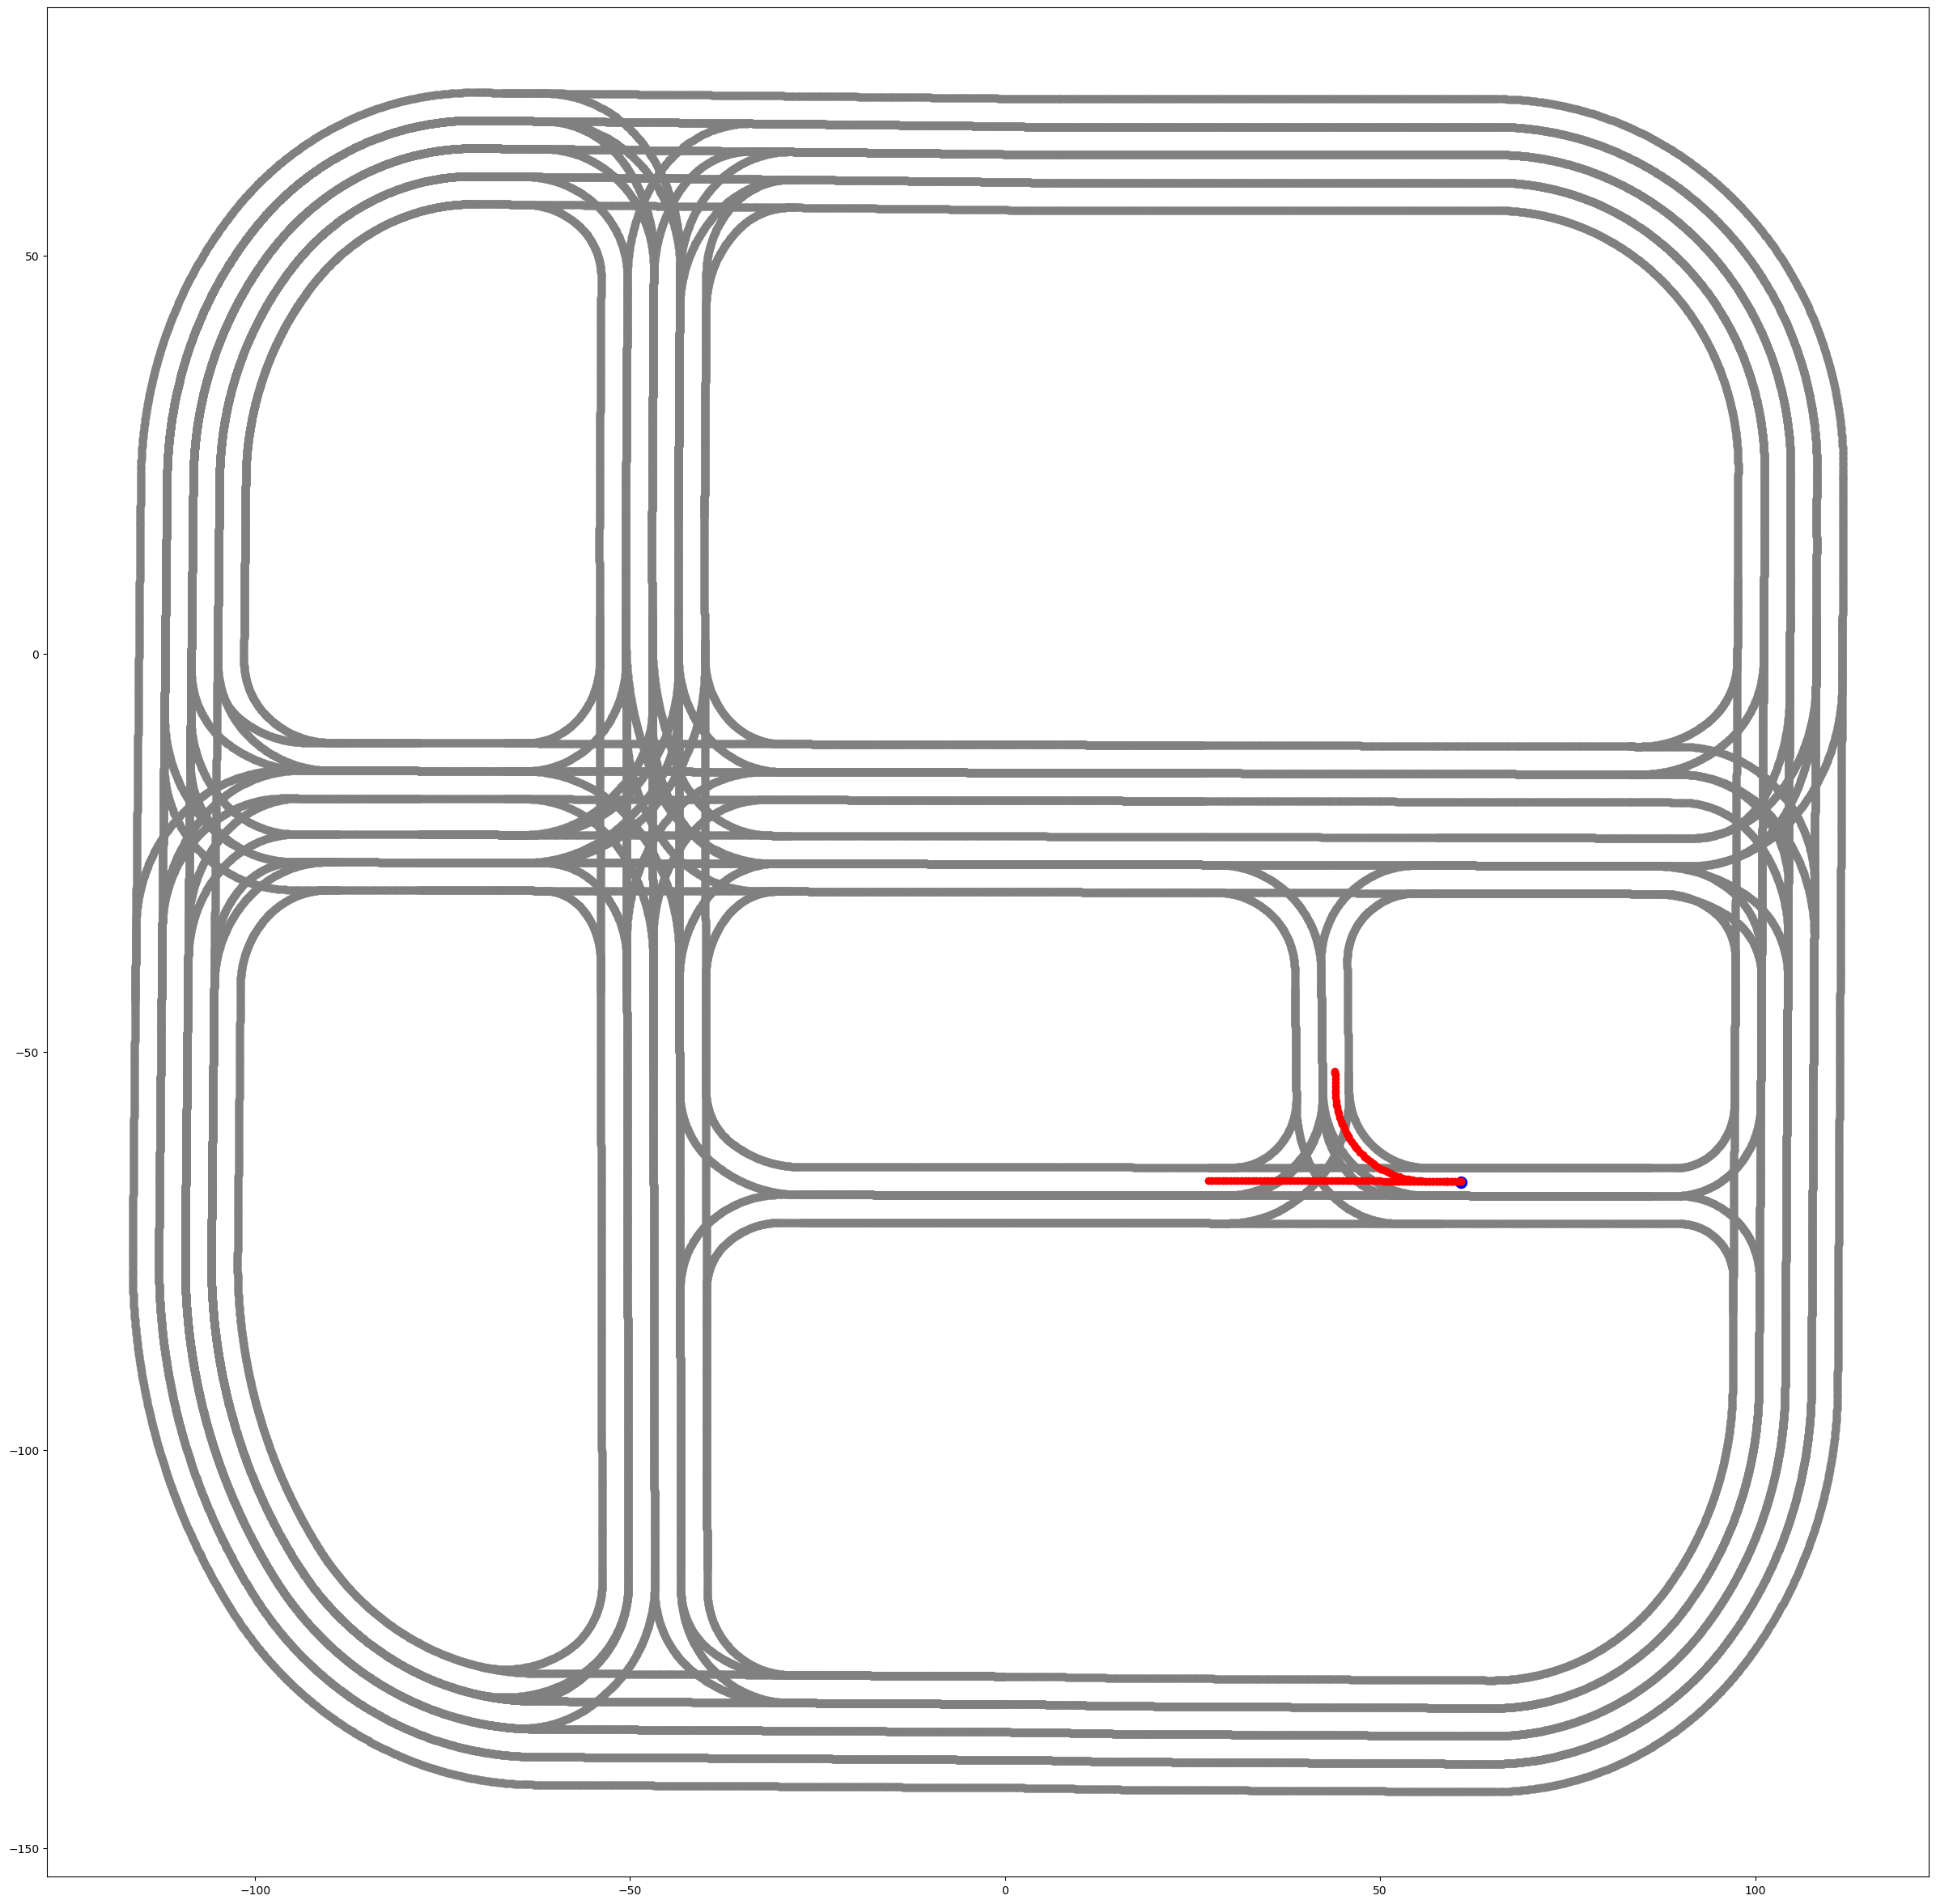

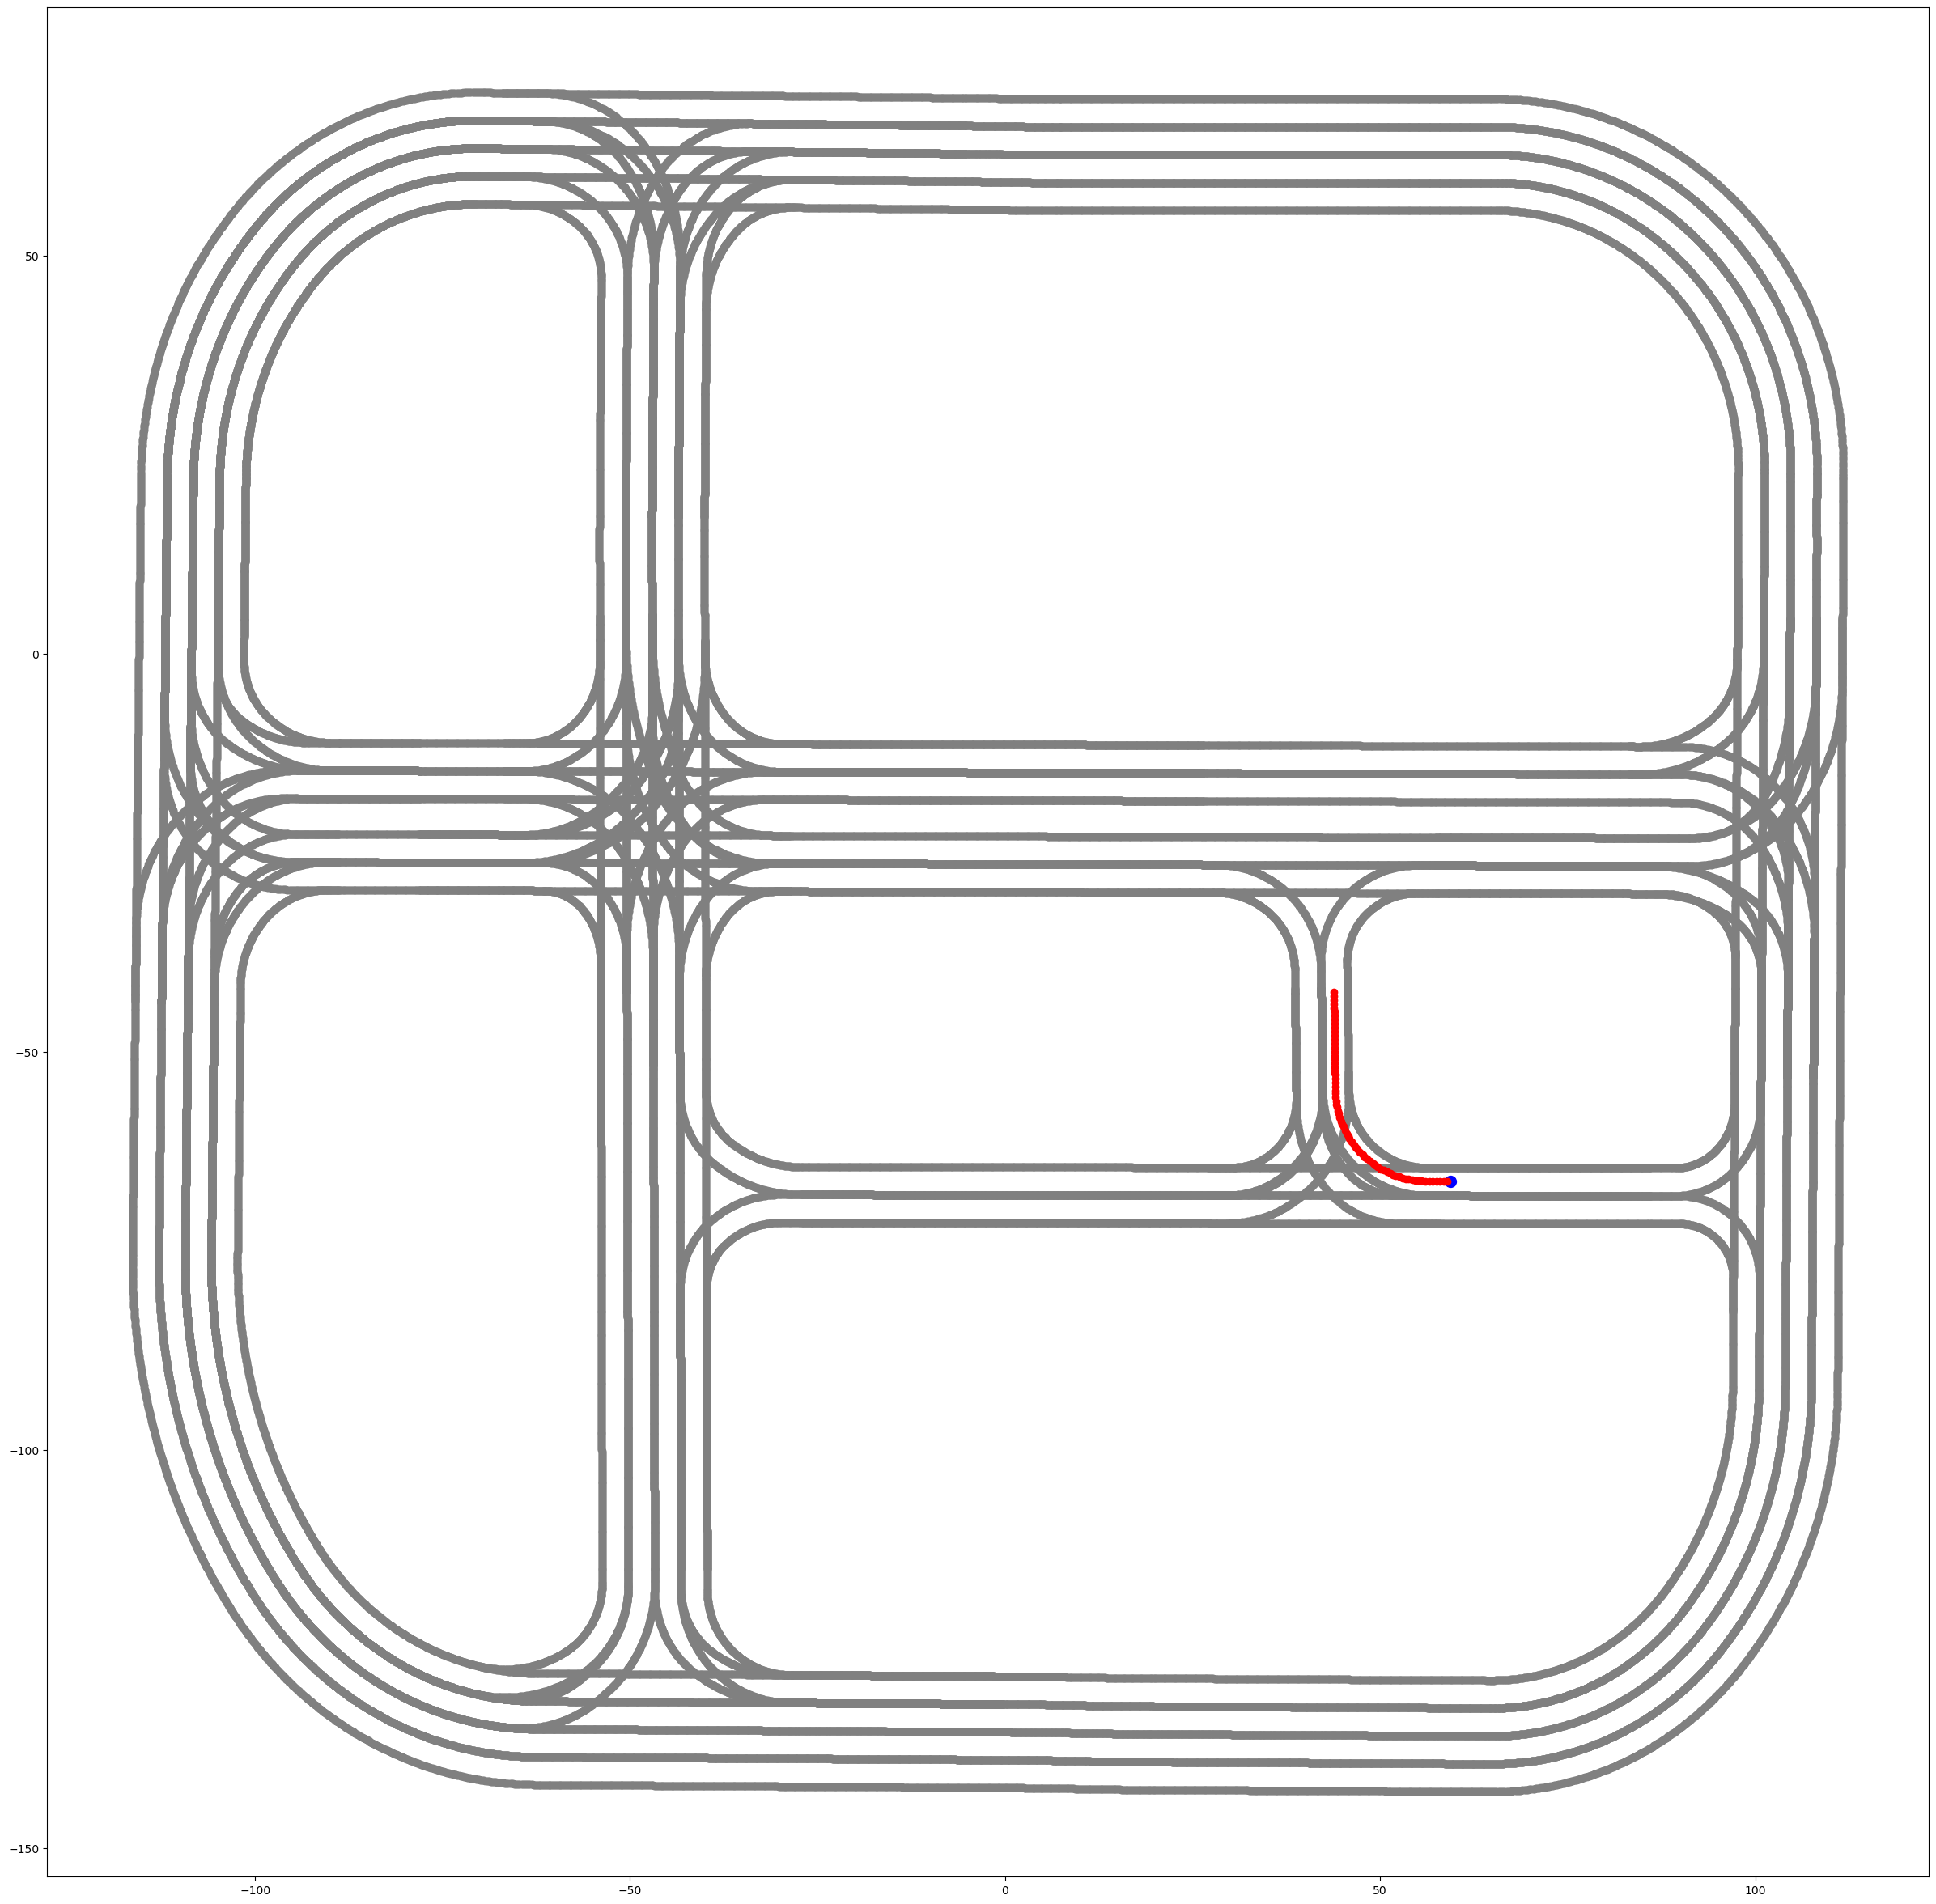

In [27]:
settings = world.get_settings()
settings.synchronous_mode = True
settings.fixed_delta_seconds = 0.05
world.apply_settings(settings)
client.set_timeout(10.0)

# Load map and setup
map_path = os.path.expanduser('~/Documents/town_10/backup/lanelet2_map.osm')
assert os.path.exists(map_path), f"Map file not found at {map_path}"
proj = LocalCartesianProjector(Origin(0, 0, 0))
lanelet_map = load(map_path, proj)
traffic_rules = create_traffic_rules("de", "vehicle")
router = RoutingGraph(lanelet_map, traffic_rules, [RoutingCostDistance(1.0)])
trajectory_dict = {}


vehicle_bp = bp_lib.find('vehicle.tesla.model3') #112
vehicle = world.spawn_actor(vehicle_bp, spawn_points[136])

tm.ignore_lights_percentage(vehicle, 100)
vehicle.set_autopilot(True, tm_port)
try:

    second = 0
    start_time = time.time()
    prev_collection_time = start_time

    while True:
        world.tick()
#--------------------------------------------------------------------------------------------------------------------
        current_time = time.time()
        if current_time - prev_collection_time >= 0.1:
            # Reset the collection time
            prev_collection_time = current_time

            # Vehicle position and heading
            pt = BasicPoint2d(vehicle.get_location().x, -vehicle.get_location().y)
            yaw = vehicle.get_transform().rotation.yaw  # in degrees
            yaw_rad = math.radians(yaw)
            v_veh = (-math.cos(yaw_rad), -math.sin(yaw_rad))  # Direction in map coordinates

            # Find candidate lanelets within 5 meters
            candidates = [ll for ll in lanelet_map.laneletLayer if lanelet2.geometry.distance(ll, pt) < 1.0]

            # Select lanelet aligned with vehicle's direction
            best_lanelet = None
            max_dot = -float('inf')
            for ll in candidates:
                # 1) Project vehicle point onto this lanelet’s 3D centerline
                pt3d    = BasicPoint3d(pt.x, pt.y, 0.0)
                proj_pt = lanelet2.geometry.project(ll.centerline, pt3d)

                # 2) Find which segment of ll.centerline is closest to proj_pt
                best_i, best_dist = 0, float('inf')
                pts = ll.centerline
                for idx in range(len(pts) - 1):
                    p0, p1 = pts[idx], pts[idx+1]
                    dx, dy = p1.x - p0.x, p1.y - p0.y
                    ux, uy = proj_pt.x - p0.x, proj_pt.y - p0.y
                    denom  = dx*dx + dy*dy
                    u = (ux*dx + uy*dy) / denom if denom > 0 else 0.0
                    u_clamped = max(0.0, min(1.0, u))
                    cx, cy = p0.x + u_clamped*dx, p0.y + u_clamped*dy
                    d = math.hypot(cx - pt.x, cy - pt.y)
                    if d < best_dist:
                        best_dist, best_i = d, idx
                
                # 3) Compute this lanelet’s local direction vector
                p0 = pts[best_i]
                p1 = pts[best_i+1]
                v_lane = (p1.x - p0.x, p1.y - p0.y)

                # 4) Compute dot with vehicle’s heading unit vector v_veh
                dot = v_lane[0]*v_veh[0] + v_lane[1]*v_veh[1]
                if dot > max_dot:
                    max_dot     = dot
                    best_lanelet = ll

            if second == 2 or second == 3:
                all_paths = collect_trajectories_v3(
                    lanelet_map,
                    router,
                    best_lanelet,
                    pt3d,
                    budget=50.0,
                    connection_tol=1.0,
                    enter_threshold=2.0,
                )

                best_lanelet_trajectory = get_full_trajectory(best_lanelet, router, 50.0, 3.0)
                best_lanelet_trajectory = np.array(best_lanelet_trajectory)
                print('-'*20)
                
                fig, ax = plt.subplots(figsize=(30,30))
                ax.scatter(vehicle.get_location().x, -vehicle.get_location().y, c="blue", s=100)
                ax.scatter(road_boundary_coord[:, 0], road_boundary_coord[:, 1], c="gray")
                #ax.scatter(best_lanelet_trajectory[:, 0], best_lanelet_trajectory[:, 1], c="red")
                

                trajectory_dict[second] = {}
                trajectory_dict[second]["trajectories"] = []
                for traj in all_paths:
                    sliced_trajectory = [(p.x, p.y) for p in traj]
                    trajectory_dict[second]["trajectories"].append(sliced_trajectory)
                    
                    sliced_trajectory = np.array(sliced_trajectory)
                    ax.scatter(sliced_trajectory[:, 0], sliced_trajectory[:, 1], c="red")
                
                        
            if second == 10:
                break

            

            print("second:", second)
            second+=1
            
#--------------------------------------------------------------------------------------------------------------------
        
        

except KeyboardInterrupt:
    print("User interrupted the script.")
finally:
    vehicle.set_autopilot(False)
    settings.fixed_delta_seconds = 0
    settings.synchronous_mode = False
    world.apply_settings(settings)

    for vehicle in world.get_actors().filter('*vehicle*'):
        vehicle.destroy()

In [13]:
print(trajectory_dict[0])

{'trajectories': [[(61.60271565080941, -66.26242182165244), (61.422009852675835, -66.26219010157807), (60.92250155471134, -66.26154959372738), (60.42299135535355, -66.26091289681911), (59.92348115605427, -66.2602761854809), (59.42397096087309, -66.25963566314499), (58.92446076568902, -66.25899515529431), (58.92446076568902, -66.25899515529431), (58.45991613549545, -66.25840038422605), (57.99537150529922, -66.25780562653728), (57.495861318075995, -66.25716510420136), (56.99635113084989, -66.25652459635069), (56.51157412014007, -66.25571641411044), (56.01206393725761, -66.25482436846934), (55.51315590220753, -66.2325032938852), (55.136503467311016, -66.2156472158816), (54.761954698783, -66.17249170285467), (54.265828688425245, -66.11531939932256), (53.77491990584312, -66.02358169106206), (53.404311686322615, -65.9543211034523), (53.03945041060044, -65.85930605100279), (52.55615976011755, -65.73345263353133), (52.08285956383209, -65.57408945144772), (51.7255420990865, -65.45378106178441),

In [14]:
with open("./road_boundary_coord.json", "r") as file:
    road_boundary_coord = json.load(file)

with open("./road_center_coord.json", "r") as file:
    road_center_coord = json.load(file)

road_center_coord = np.array(road_center_coord)
road_boundary_coord = np.array(road_boundary_coord)

In [15]:
print(len(trajectory_dict.keys()))

for i in range(10):
    #plt.figure(figsize=(30, 30))
    fig, ax = plt.subplots(figsize=(30,30))
    ax.scatter(road_boundary_coord[:, 0], road_boundary_coord[:, 1], c="gray")
    plot_color = ["red", "blue", "green"]
    color_idx = 0
    for trajectory in trajectory_dict[i]["trajectories"]:
        trajectory = np.array(trajectory)
        ax.scatter(trajectory[:, 0], trajectory[:, 1], c=plot_color[color_idx], alpha=0.5)
        color_idx += 1
    plt.title(len(trajectory_dict[i]["trajectories"]))
    if i == 7:
        for trajectory in trajectory_dict[i]["trajectories"]:
            trajectory = np.array(trajectory)
            print(trajectory)

    plt.savefig(f"./plot/{i}.png")
    plt.close()


11
[[ 56.8953338  -66.25635619]
 [ 56.51157412 -66.25571641]
 [ 56.01206394 -66.25482437]
 [ 55.5131559  -66.23250329]
 [ 55.13650347 -66.21564722]
 [ 54.7619547  -66.1724917 ]
 [ 54.26582869 -66.1153194 ]
 [ 53.77491991 -66.02358169]
 [ 53.40431169 -65.9543211 ]
 [ 53.03945041 -65.85930605]
 [ 52.55615976 -65.73345263]
 [ 52.08285956 -65.57408945]
 [ 51.7255421  -65.45378106]
 [ 51.37751768 -65.30877575]
 [ 50.916525   -65.11670311]
 [ 50.47009973 -64.89283945]
 [ 50.13307185 -64.72383462]
 [ 49.70339958 -64.46929275]
 [ 49.37902029 -64.27712492]
 [ 49.06887875 -64.0627411 ]
 [ 48.65806695 -63.7787672 ]
 [ 48.2681316  -63.46674845]
 [ 47.97374839 -63.23119095]
 [ 47.70072563 -62.97922919]
 [ 47.33382373 -62.64043275]
 [ 46.9936424  -62.27483004]
 [ 46.74485925 -62.00745106]
 [ 46.51730888 -61.72178519]
 [ 46.20616517 -61.33117307]
 [ 45.92589405 -60.91785146]
 [ 45.72092363 -60.61557745]
 [ 45.5397355  -60.2984731 ]
 [ 45.29198522 -59.8648753 ]
 [ 45.07821537 -59.41355274]
 [ 44.92187